# L13 - Comparing Segmentation Approaches using Image Processing and U-Nets

Directions:

1. Please rename the file by clicking on “LX-First-Last.ipynb” where X is the lab number, and replace First and Last with your first and last name.

2. Click File -> Save to make sure your most recent edits are saved.

3. In the upper right hand corner of the screen, click on “Share”. Click on “Restricted” and change it to “Anyone with the link”. Make sure you also share it with `ahaberlie1@gmail.com`.

4. Copy the link and submit it on Blackboard. Make sure you follow these steps completely, or I will be unable to grade your work.

### Overview

This lab will help you understand storm segmentation using basic and ML approaches in PyTorch.

You can use generative AI to help answer these problems. **The answer should still be in your own words.** Think of the generative AI descriptions as those from a book. You still have to cite your source and you cannot plagiarize directly from the source. For every question that you used generative AI for help, please reference the generative AI you used and what your prompt or prompts were.

However, it is crucial that you understand the code well enough to effectively use generative AI tools that are likely to be widely available and recommended for use at many organizations. Although they are improving at an incredible rate, they still produce bugs, especially with domain-specific and complex problems. Make sure that you verify the answers before putting them in your own words.

### scikit-image

This package, sometimes called ["skimage"](https://scikit-image.org/), provides an interface to many methods for digital image processing. We will work with both RGB (3, y, x) and grayscale images (y, x).

### PyTorch

This package is the most popular machine learning package for visual / spatial applications. We will use in this class to segment a grayscale image. I will have you restart your session and connect to a GPU instance halfway through the lab.

Install the required packages

In [1]:
!git clone https://github.com/ahaberlie/SVRIMG.git > /dev/null
!cd SVRIMG && pip install . > /dev/null
!pip install cartopy > /dev/null
!pip install scikit-learn > /dev/null

Cloning into 'SVRIMG'...
remote: Enumerating objects: 764, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 764 (delta 30), reused 27 (delta 27), pack-reused 729 (from 1)
Receiving objects: 100% (764/764), 24.27 MiB | 15.09 MiB/s, done.
Resolving deltas: 100% (403/403), done.


In [1]:
import warnings
warnings.filterwarnings('ignore')

### Image segmentation

The first part of this notebook will examine manual segmentation. We will address the following questions:

1. How do we translate raw image data into objects?
2. How do we translate pixel sizes to "real world" sizes?
3. How do we translate subjective meteorological definitions into rules a computer can use?
4. How do we create a training dataset of segmented images?
5. What is transfer learning? How do you get it to work with your application?
6. What are the differences between segmentation accuracy (pixel-based) and image classification accuracy (label-based)? What are some common issues for assessing segmentation models?

You can use a regular CPU instance for these steps. Don't waste your GPU time until lower in the notebook when I tell you to switch.

Like with the CNN example, we will just use the SVRIMG labeled data as it is conveniently available to us.

In [2]:
from svrimg.utils.get_images import get_example_data

(x_train, y_train) = get_example_data('training', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_val, y_val) = get_example_data('validation', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_test, y_test) = get_example_data('testing', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")

### Download the manual segmentation code

This may be in a future version of SVRIMG, but it is the implementation described in:

Haberlie, A. M., and W. S. Ashley, 2018: Identifying mesoscale convective systems in radar mosaics. Part I. Segmentation and classification. Journal of Applied Meteorology and Climatology, 57, 1575-1598. https://doi.org/10.1175/JAMC-D-17-0293.1

which is based on the subjective definition described in:

Parker, Matthew D., and Richard H. Johnson, 2000: Organizational modes of midlatitude mesoscale convective systems. Monthly weather review, 128, 3413-3436. <a href="https://doi.org/10.1175/1520-0493(2001)129<3413:OMOMMC>2.0.CO;2">"https://doi.org/10.1175/1520-0493(2001)129<3413:OMOMMC>2.0.CO;2"</a>

In [3]:
!wget -nc https://nimbus.niu.edu/svrimg/segmentation/mcs_segment.py > /dev/null

File ‘mcs_segment.py’ already there; not retrieving.



### Select a sample from ```x_test```

<Axes: xlabel='km', ylabel='km'>

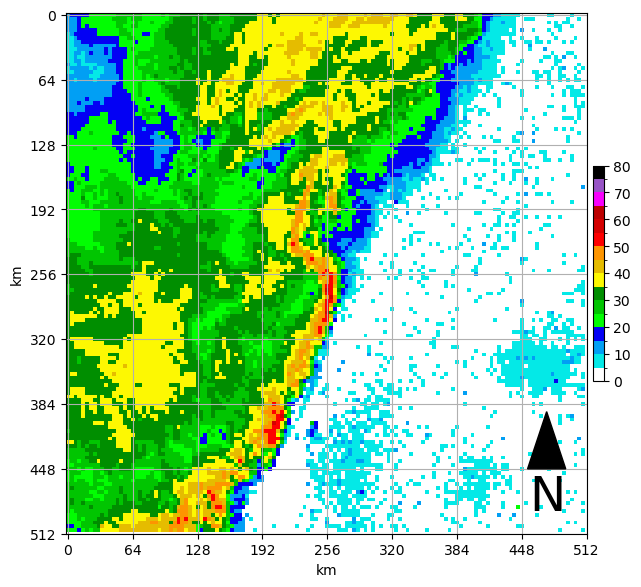

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = 8, 8

from svrimg.mapping.map_helper import draw_box_plot

sample = x_test[220]
ax = plt.subplot(1,1,1)
draw_box_plot(ax, sample.squeeze())

### Set up the parameters of the segmentation process and import the helper functions

Default values are based on Haberlie and Ashley (2018) and the identification of mesoscale convective systems (MCSs):

- ```grid_spacing``` - the approximate distance between grid cells in km (default = 3.75)
- ```grid_area``` - the approximate area covered by a pixel in km$^{2}$ (default = 3.75**2 = 14.0625)
- ```minimum_stratiform_intensity``` - minimum dBZ of "stratiform" pixels (default= 20)
- ```minimum_convective_intensity``` - minimum dBZ of "convection" pixels (default=40)
- ```minimum_intense_intensity``` - minimum dBZ of "intense convection" pixels (default=50)
- ```minimum_convective_cell_size``` - smallest size of a cluster of pixels, in km$^{2}$, bounded by *minimum_convective_intensity* that has at least one pixel equal to or greater than *minimum_intense_intensity*. Meeting these criteria would make the cluster a proxy for a robust updraft characteristic of an MCS. The minimum size is based on Figure 6 in Byers and Braham (1948) that describes the typical horizontal size of a single-cell updraft as approximately 4x4 miles, which is approximately 40 km$^{2}$. This is to remove noise like wind farms and other non-meteorological echoes that sometimes produce high dBZ values (default = 40)
- ```convective_cell_neighborhood``` - search radius, in km, within which cells that are not connected by *minimum_convective_intensity* pixels are combined into a single cluster based on discussions in Parker and Johnson (2000) about the characteristic distances at which cells interact with eachother (i.e., are part of a "system"). This will connect cells that otherwise would be counted as different clusters using binary_closing, which is a binary dilation followed by a binary erosion that leaves behind virtual bridges between cells, as implemented in the function ```mcs_segment.connect_regions``` (default = 24)
- ```minimum_line_length``` - minimum length, in km, of the major axis of a linear cluster of pixels, bounded by a polygon of a virtual cluster of convective cells meeting the *minimum_convective_intensity* and *minimum_intense_intensity* that are within *convective_cell_neighborhood* of eachother, even if they are not touching. This is based on the Parker and Johnson (2000) definition (default = 100).
- ```stratiform_neighborhood``` - the distance, in km, within which all pixels greater than *minimum_stratiform_intensity* are connected to a qualifying MCS linear segment. This is based on the Parker and Johnson (2000) definition which describes stratiform regions as an important part of the MCS.

<Axes: xlabel='km', ylabel='km'>

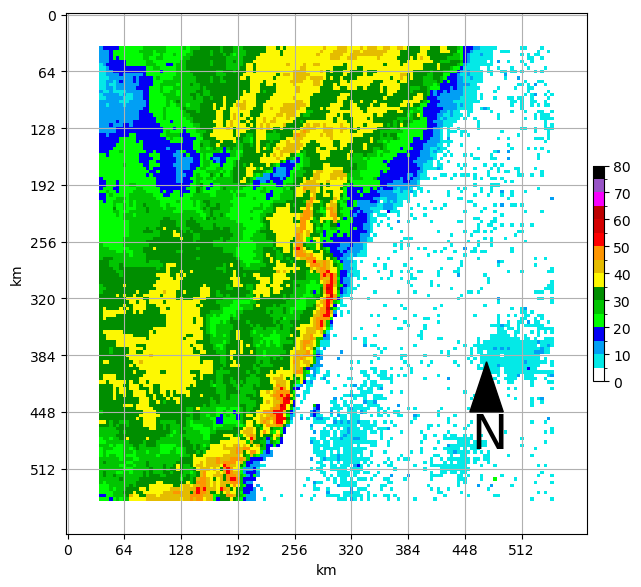

In [5]:
import numpy as np
from mcs_segment import (find_intense_convective_regions, connect_regions,
                         find_long_regions, find_stratiform_neighborhood,
                         connect_stratiform, geog_to_pixel)

segmentation_values = {'grid_spacing': {'value': 3.75, 'units': 'km pixel^-1'},
                       'grid_area': {'value': 3.75**2, 'units': 'km^2 pixel^-1'},
                       'minimum_stratiform_intensity': {'value': 20, 'units': 'dBZ'},
                       'minimum_convective_intensity': {'value': 40, 'units': 'dBZ'},
                       'minimum_intense_intensity': {'value': 50, 'units': 'dBZ'},
                       'minimum_convective_cell_size': {'value': 40, 'units': 'km^2'},
                       'convective_cell_neighborhood': {'value': 24, 'units': 'km'},
                       'minimum_line_length': {'value': 100, 'units': 'km'},
                       'stratiform_neighborhood': {'value': 96, 'units': 'km'}}

# set up conversions
conv_seg_args = geog_to_pixel(segmentation_values)

# pad the edges of the sample to prevent edge issues
pad_val = 10
padded_sample = np.pad(sample.squeeze(), (pad_val, pad_val), mode='constant')

ax = plt.subplot(1,1,1)

#demonstrate padding
draw_box_plot(ax, padded_sample)

### Find convective regions with at least one intense pixel

This uses label and regionprops to find regions and attributes.

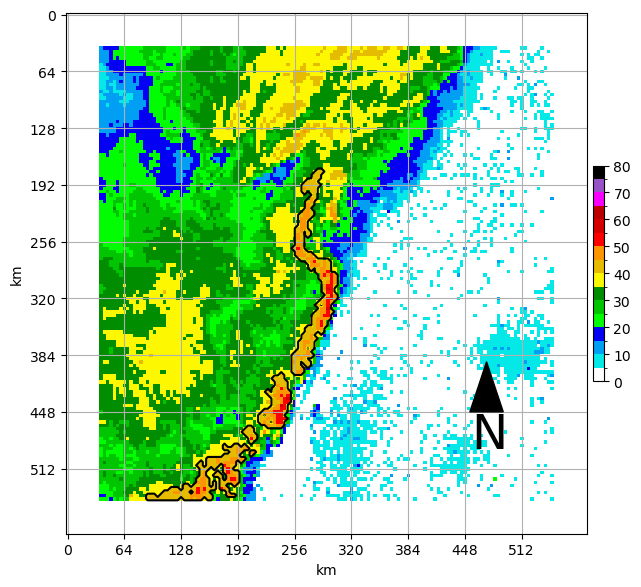

In [6]:
int_regions = find_intense_convective_regions(padded_sample, conv_seg_args['minimum_convective_intensity'],
                                              conv_seg_args['minimum_intense_intensity'],
                                              conv_seg_args['minimum_convective_cell_size'])

ax = plt.subplot(1,1,1)
draw_box_plot(ax, padded_sample)
ax.contour(np.flipud(int_regions), [0.5], colors='k')

### Connect regions that are within the specified distance

This uses ```binary_closing``` to vritually bridge gaps between convective regions

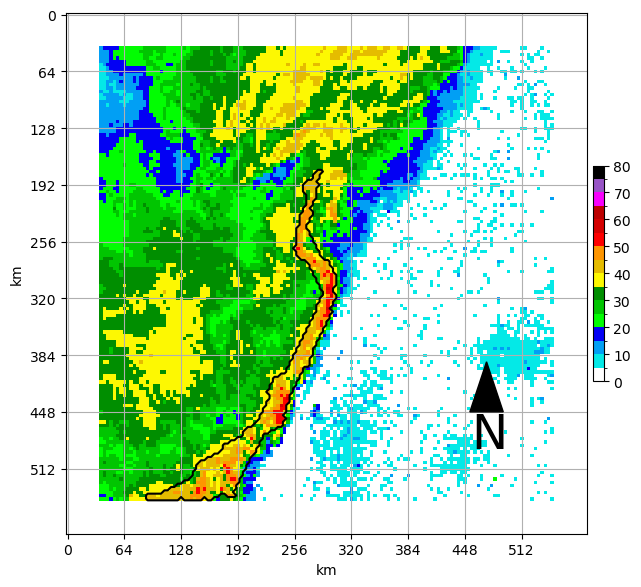

In [7]:
close_regions = connect_regions(int_regions, conv_seg_args['convective_cell_neighborhood'])

ax = plt.subplot(1,1,1)
draw_box_plot(ax, padded_sample)
ax.contour(np.flipud(close_regions), [0.5], colors='k')

### Find regions that are longer than the specified distance

Label and regionprops are run again to find the attributes of regions.

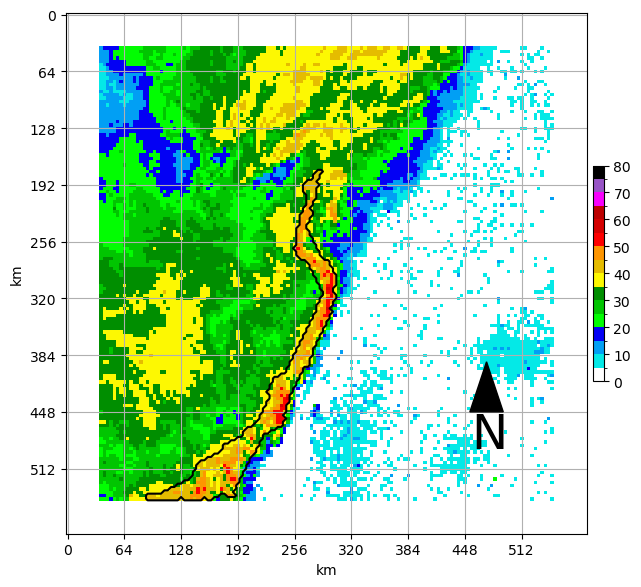

In [8]:
long_regions = find_long_regions(close_regions, conv_seg_args['minimum_line_length'])

ax = plt.subplot(1,1,1)
draw_box_plot(ax, padded_sample)
ax.contour(np.flipud(long_regions), [0.5], colors='k')

### Identify stratiform regions and connect them to the qualifying lines

This uses ```binary_dilation``` around qualifying lines to attach stratiform and other regions as a complete MCS.

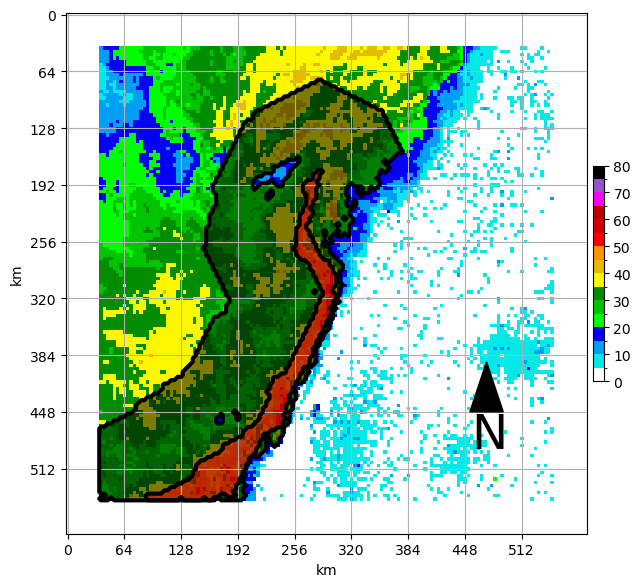

In [9]:
mask = find_stratiform_neighborhood(padded_sample, long_regions, conv_seg_args['minimum_stratiform_intensity'], conv_seg_args['stratiform_neighborhood'])
mcs_outline = connect_stratiform(long_regions, mask)

ax = plt.subplot(1,1,1)
draw_box_plot(ax, padded_sample)
ax.contourf(np.flipud(mcs_outline), [0.5, 1], colors='k', alpha=0.5)
ax.contourf(np.flipud(long_regions), [0.5, 1], colors='r', alpha=0.5)

ax.contour(np.flipud(mcs_outline), [0.5], colors='k', linewidths=3,)
ax.contour(np.flipud(long_regions), [0.5], colors='k', linewidths=3)

### All in one plot using a widget to explore the segmentation parameters

First set new dictionary values in the interactive widget below

In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

segmentation_values = {'grid_spacing': {'value': 3.75, 'units': 'km pixel^-1'},
                       'grid_area': {'value': 3.75**2, 'units': 'km^2 pixel^-1'},
                       'minimum_stratiform_intensity': {'value': 20, 'units': 'dBZ'},
                       'minimum_convective_intensity': {'value': 40, 'units': 'dBZ'},
                       'minimum_intense_intensity': {'value': 50, 'units': 'dBZ'},
                       'minimum_convective_cell_size': {'value': 40, 'units': 'km^2'},
                       'convective_cell_neighborhood': {'value': 24, 'units': 'km'},
                       'minimum_line_length': {'value': 100, 'units': 'km'},
                       'stratiform_neighborhood': {'value': 96, 'units': 'km'}}

# Create widgets for each parameter
widgets_dict = {}

for key, value in segmentation_values.items():
    widgets_dict[key] = widgets.FloatText(
        value=value['value'],
        description=key,
        disabled=False,
        continuous_update=False,
        display='flex',
        flex_flow='column',
        align_items='stretch',
        style= {'description_width': 'initial'}
    )

# Display the widgets
for widget in widgets_dict.values():
    display(widget)

# Function to print the current values (you'd replace this with your processing)
def print_values():
    print("Current Segmentation Values:")
    for key, widget in widgets_dict.items():
        segmentation_values[key]['value'] = widget.value
        print(f"{key}: {segmentation_values[key]['value']} {segmentation_values[key]['units']}")
    print("-" * 20)


# Button to trigger the processing
button = widgets.Button(description="Set Parameters")
display(button)

button.on_click(lambda b: print_values())

FloatText(value=3.75, description='grid_spacing', style=DescriptionStyle(description_width='initial'))

FloatText(value=14.0625, description='grid_area', style=DescriptionStyle(description_width='initial'))

FloatText(value=20.0, description='minimum_stratiform_intensity', style=DescriptionStyle(description_width='in…

FloatText(value=40.0, description='minimum_convective_intensity', style=DescriptionStyle(description_width='in…

FloatText(value=50.0, description='minimum_intense_intensity', style=DescriptionStyle(description_width='initi…

FloatText(value=40.0, description='minimum_convective_cell_size', style=DescriptionStyle(description_width='in…

FloatText(value=24.0, description='convective_cell_neighborhood', style=DescriptionStyle(description_width='in…

FloatText(value=100.0, description='minimum_line_length', style=DescriptionStyle(description_width='initial'))

FloatText(value=96.0, description='stratiform_neighborhood', style=DescriptionStyle(description_width='initial…

Button(description='Set Parameters', style=ButtonStyle())

### Run segmentation example based on those parameters

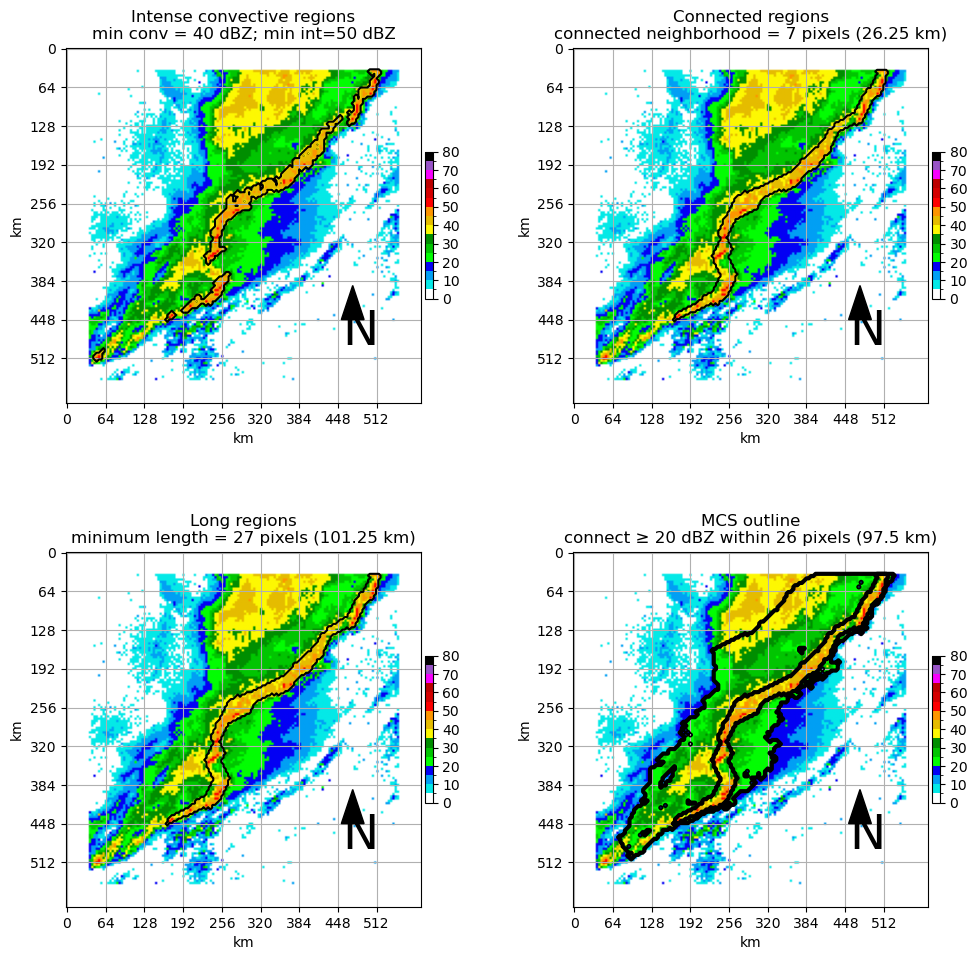

In [11]:
plt.rcParams['figure.figsize'] = 12, 12

sample = x_test[194]
# set up conversions
conv_seg_args = geog_to_pixel(segmentation_values)

# pad the edges of the sample to prevent edge issues
pad_val = 10
padded_sample = np.pad(sample.squeeze(), (pad_val, pad_val), mode='constant')

# run each step using the parameters set in the previous cell
int_regions = find_intense_convective_regions(padded_sample, conv_seg_args['minimum_convective_intensity'],
                                              conv_seg_args['minimum_intense_intensity'],
                                              conv_seg_args['minimum_convective_cell_size'])
close_regions = connect_regions(int_regions, conv_seg_args['convective_cell_neighborhood'])
long_regions = find_long_regions(close_regions, conv_seg_args['minimum_line_length'])
mask = find_stratiform_neighborhood(padded_sample, long_regions, conv_seg_args['minimum_stratiform_intensity'], conv_seg_args['stratiform_neighborhood'])
mcs_outline = connect_stratiform(long_regions, mask)

### Plot a multi-panel plot for each output

ax = plt.subplot(2,2,1)
ax.set_title(f"Intense convective regions\nmin conv = {conv_seg_args['minimum_convective_intensity']} dBZ; min int={conv_seg_args['minimum_intense_intensity']} dBZ")
draw_box_plot(ax, padded_sample)
ax.contour(np.flipud(int_regions), [0.5], colors='k')

ax = plt.subplot(2,2,2)
ax.set_title(f"Connected regions\nconnected neighborhood = {conv_seg_args['convective_cell_neighborhood']} pixels ({conv_seg_args['convective_cell_neighborhood']*conv_seg_args['grid_spacing']} km)")
draw_box_plot(ax, padded_sample)
ax.contour(np.flipud(close_regions), [0.5], colors='k')

ax = plt.subplot(2,2,3)
ax.set_title(f"Long regions\nminimum length = {conv_seg_args['minimum_line_length']} pixels ({conv_seg_args['minimum_line_length']*conv_seg_args['grid_spacing']} km)")
draw_box_plot(ax, padded_sample)
ax.contour(np.flipud(long_regions), [0.5], colors='k')

ax = plt.subplot(2,2,4)
ax.set_title(f"MCS outline\nconnect ≥ {conv_seg_args['minimum_stratiform_intensity']} dBZ within {conv_seg_args['stratiform_neighborhood']} pixels ({conv_seg_args['stratiform_neighborhood']*conv_seg_args['grid_spacing']} km)")
draw_box_plot(ax, padded_sample)
ax.contourf(np.flipud(mcs_outline), [0.5, 1], colors='k', alpha=0.5)
ax.contourf(np.flipud(long_regions), [0.5, 1], colors='r', alpha=0.5)

ax.contour(np.flipud(mcs_outline), [0.5], colors='k', linewidths=3)
ax.contour(np.flipud(long_regions), [0.5], colors='k', linewidths=3)

### When you like what you see, run the segmentation on all of the images and pick out examples. Try to figure out how to plot the original image next to the segmentation output.

Function that simplifies running the segmentation

In [12]:
def full_seg(input_arr, seg_values):

    # set up conversions
    conv_seg_args = geog_to_pixel(seg_values)

    # pad the edges of the sample to prevent edge issues
    pad_val = 10
    padded_sample = np.pad(input_arr.squeeze(), (pad_val, pad_val), mode='constant')

    # run each step using the parameters set in the previous cell
    int_regions = find_intense_convective_regions(padded_sample, conv_seg_args['minimum_convective_intensity'],
                                                  conv_seg_args['minimum_intense_intensity'],
                                                  conv_seg_args['minimum_convective_cell_size'])
    close_regions = connect_regions(int_regions, conv_seg_args['convective_cell_neighborhood'])
    long_regions = find_long_regions(close_regions, conv_seg_args['minimum_line_length'])
    mask = find_stratiform_neighborhood(padded_sample, long_regions, conv_seg_args['minimum_stratiform_intensity'], conv_seg_args['stratiform_neighborhood'])
    mcs_outline = connect_stratiform(long_regions, mask)

    return long_regions, mcs_outline, padded_sample

# Problem 1

Demonstrate segmentation pixel input and segmentation pixel output using side-by-side figures by choosing 5 of the train_seg_x and train_seg_y examples. You can randomly choose the 5 based on examples you think are cool or for any other reason.

Left side in each row: The original radar image

Right side in each row: The segmented radar image (only segmented pixels, not the original)

In [13]:
train_seg_x = []
train_seg_y = []

for sample in x_train:

    intense_lines, mcs_outline, padded_img = full_seg(sample, segmentation_values)

    train_seg_x.append(padded_img)
    train_seg_y.append(1*(mcs_outline>0) + 1*(intense_lines>0))

Plot 5 examples

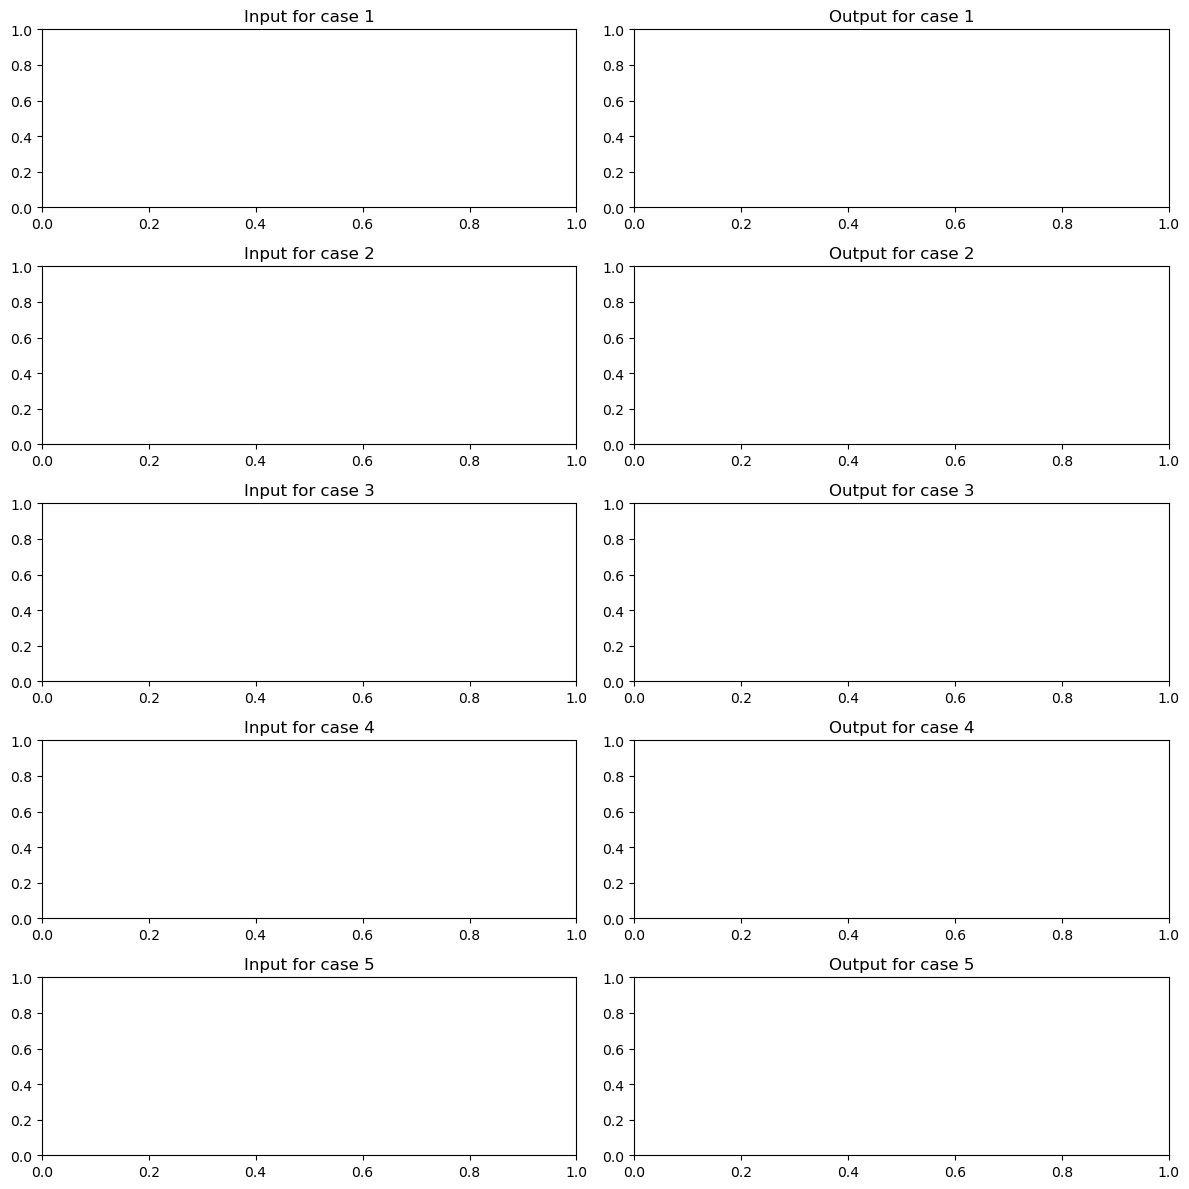

In [14]:
plt.rcParams['figure.figsize'] = 12, 12

# case 1
ax = plt.subplot(5, 2, 1)
ax.set_title("Input for case 1")

ax = plt.subplot(5, 2, 2)
ax.set_title("Output for case 1")

# case 2
ax = plt.subplot(5, 2, 3)
ax.set_title("Input for case 2")

ax = plt.subplot(5, 2, 4)
ax.set_title("Output for case 2")

# case 3
ax = plt.subplot(5, 2, 5)
ax.set_title("Input for case 3")

ax = plt.subplot(5, 2, 6)
ax.set_title("Output for case 3")

# case 4
ax = plt.subplot(5, 2, 7)
ax.set_title("Input for case 4")

ax = plt.subplot(5, 2, 8)
ax.set_title("Output for case 4")

# case 5
ax = plt.subplot(5, 2, 9)
ax.set_title("Input for case 5")

ax = plt.subplot(5, 2, 10)
ax.set_title("Output for case 5")

plt.tight_layout()

# Simple U-Net Segmentation process

A U-Net is composed of two parts:

1. An **encoder** - this part of the U-Net is very similar to the convolutional layers in a CNN. It transforms the image based on a series convolutions using learned filters/kernels

2. A **decoder** - this is like an inverse convolutional layer. It learns how to take the image transform from the encoder and turn it into pixel classifications using a series of "deconvolutions".

There is no dense layer in this type of model. The output is created using the compressed image representations from the encoder that are decoded into an image that represents a segmentation output. In this case, it will be the same size as the input image.

The model learns how to transform an input image into a segmented (pixel-based classification) image. Think of each pixel as a classification decision.

In our case:

**0**: this is a background pixel and was deemed to be outside of the MCS

**1**: this is a pixel within an MCS, but not within the intense line of the MCS

**2**: this is a pixel within an intense line

 As you can imagine, we can have extreme class imbalance (by design), so we have to use approaches to maximize the performance on non-zero pixels. We will get to this in a bit.

 # Redo all of the steps below on a GPU instance. This will delete all your progress thus far.

In [1]:
!wget https://nimbus.niu.edu/svrimg/segmentation/mcs_segment.py > /dev/null
!git clone https://github.com/ahaberlie/SVRIMG.git > /dev/null
!cd SVRIMG && pip install . > /dev/null
!pip install cartopy > /dev/null
!pip install scikit-learn > /dev/null
!pip install torch torchvision torchmetrics > /dev/null
!pip install cmweather

--2026-04-22 19:28:42--  https://nimbus.niu.edu/svrimg/segmentation/mcs_segment.py
Resolving nimbus.niu.edu (nimbus.niu.edu)... 131.156.225.123
Connecting to nimbus.niu.edu (nimbus.niu.edu)|131.156.225.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6566 (6.4K) [text/plain]
Saving to: ‘mcs_segment.py’

mcs_segment.py      100%[===================>]   6.41K  --.-KB/s    in 0s      

2026-04-22 19:28:43 (144 MB/s) - ‘mcs_segment.py’ saved [6566/6566]

Cloning into 'SVRIMG'...
remote: Enumerating objects: 764, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 764 (delta 1), reused 0 (delta 0), pack-reused 758 (from 1)
Receiving objects: 100% (764/764), 24.27 MiB | 22.95 MiB/s, done.
Resolving deltas: 100% (402/402), done.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

from svrimg.utils.get_images import get_example_data

(x_train, y_train) = get_example_data('training', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_val, y_val) = get_example_data('validation', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_test, y_test) = get_example_data('testing', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")

minimum = np.min(x_train)
maximum = np.max(x_train)

from mcs_segment import (find_intense_convective_regions, connect_regions,
                         find_long_regions, find_stratiform_neighborhood,
                         connect_stratiform, geog_to_pixel)

segmentation_values = {
    'minimum_stratiform_intensity': {'value': 20, 'units': 'dBZ'},
    'minimum_convective_intensity': {'value': 40, 'units': 'dBZ'},
    'minimum_intense_intensity': {'value': 50, 'units': 'dBZ'},
    'minimum_line_length': {'value': 100, 'units': 'km'},
    'convective_cell_neighborhood': {'value': 24, 'units': 'km'},
    'stratiform_neighborhood': {'value': 96, 'units': 'km'},
    'minimum_convective_cell_size': {'value': 40, 'units': 'km^2'},
    'grid_spacing': {'value': 3.75, 'units': 'km pixel^-1'},
    'grid_area': {'value': 3.75**2, 'units': 'km^2 pixel^-1'}
}

def full_seg(input_arr, seg_values):

    # set up conversions
    conv_seg_args = geog_to_pixel(seg_values)

    # pad the edges of the sample to prevent edge issues
    pad_val = 10
    padded_sample = np.pad(input_arr.squeeze(), (pad_val, pad_val), mode='constant')

    # run each step using the parameters set in the previous cell
    int_regions = find_intense_convective_regions(padded_sample, conv_seg_args['minimum_convective_intensity'],
                                                  conv_seg_args['minimum_intense_intensity'],
                                                  conv_seg_args['minimum_convective_cell_size'])
    close_regions = connect_regions(int_regions, conv_seg_args['convective_cell_neighborhood'])
    long_regions = find_long_regions(close_regions, conv_seg_args['minimum_line_length'])
    mask = find_stratiform_neighborhood(padded_sample, long_regions, conv_seg_args['minimum_stratiform_intensity'], conv_seg_args['stratiform_neighborhood'])
    mcs_outline = connect_stratiform(long_regions, mask)

    return long_regions, mcs_outline, padded_sample

data_seg = {'train_x': [], 'train_y': [], 'val_x': [], 'val_y': [], 'test_x': [], 'test_y': []}

for name, data in zip(['train_x', 'val_x', 'test_x'], [x_train, x_val, x_test]):

    for sample in data:

        intense_lines, mcs_outline, padded_img = full_seg(sample, segmentation_values)

        # convert to float and normalize
        # U-net model we are using expects 0 to 1
        padded_img = (padded_img.astype('float32'))
        padded_img = (padded_img - minimum) / (maximum - minimum)

        seg_img = np.array(1*(mcs_outline>0) + 1*(intense_lines>0)).astype('int32')

        # remove pixels and repeat image to get a 128x128 image
        padded_img = padded_img[14:-14,14:-14]
        seg_img = seg_img[14:-14,14:-14]

        # convert to get a 128x128x1 image
        padded_img = np.stack((padded_img,), axis=-1)

        # x because it is the input
        data_seg[name].append(padded_img)

        # y because it is the output
        data_seg[name.replace("_x", "_y")].append(seg_img.reshape(128, 128, 1))


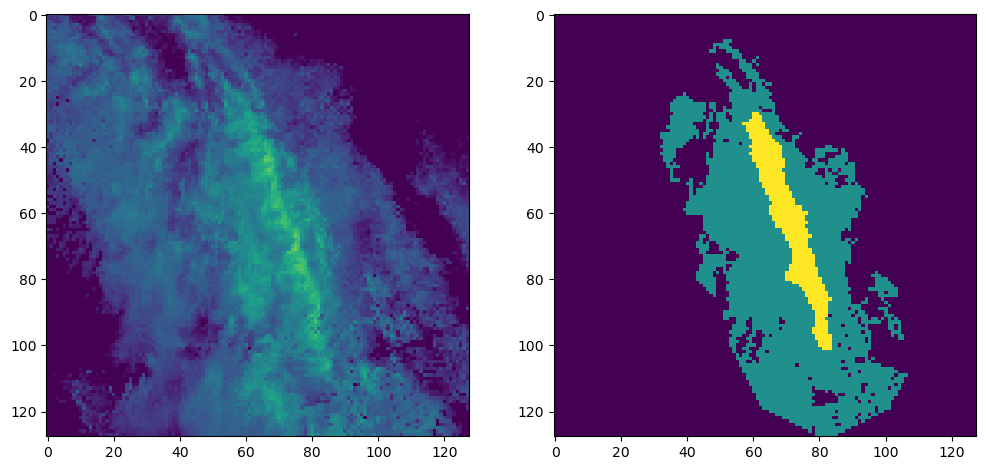

In [16]:
# plot an example of an x and a y result next to eachother after conversion
ax = plt.subplot(1, 2, 1)
ax.imshow(data_seg['train_x'][0], vmin=0, vmax=1)

ax = plt.subplot(1, 2, 2)
plt.imshow(data_seg['train_y'][0], vmin=0, vmax=2)

Set up the data using the dimension order and data types required by the PyTorch U-Net. Instead of using `numpy.ndarray`, we convert the numeric arrays into `torch.tensor`, which are the data structures PyTorch uses for efficient machine learning computation and training.

In [17]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

x_train = torch.tensor(data_seg['train_x'], dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(data_seg['train_y'], dtype=torch.long).squeeze(-1)

x_val = torch.tensor(data_seg['val_x'], dtype=torch.float32).permute(0, 3, 1, 2)
y_val = torch.tensor(data_seg['val_y'], dtype=torch.long).squeeze(-1)

x_test = torch.tensor(data_seg['test_x'], dtype=torch.float32).permute(0, 3, 1, 2)
y_test = torch.tensor(data_seg['test_y'], dtype=torch.long).squeeze(-1)

print(x_train.shape)  # (1331, 1, 128, 128)
print(y_train.shape)  # (1331, 128, 128)
print(y_train.min(), y_train.max())  # should be 0, 2

torch.Size([1331, 1, 128, 128])
torch.Size([1331, 128, 128])
tensor(0) tensor(2)


### Set up code for training steps

We will first try to create a simple U-Net model using [PyTorch](https://pytorch.org/get-started/locally/). We can easily build a model using the concepts we have learned about encoder-decoder models.

First, we will use the `torch.nn` subpackage to import methods related to building parts of machine learning pixel-wise classifier and training it. There are some important methods/classes in this subpackage that we can connect back to our exploration of image and pixel classifiers.

1. `nn.Sequential` - you can think of this as a container for your model. The individual parts of the model (convolutions, activations, etc.) will be placed in this container.

2. `nn.Conv2d` - this is your convolutional layer. You have to identify the input image channels (1 for grey, 3 for rgb, etc.), output image channels (how many different filter outputs are created), kernel size (size of filter) and padding (similar to mode='valid').

3. `nn.ReLU` - the ReLU activation (e.g., `np.maximum(0, conv_output)`)

4. `nn.MaxPool2d` - just like our max pooling step. The most important argument here is the size of the neighborhood.

5. `nn.ModuleDict` - we will build the encoder-decoder parts and store those sequentially into a dictionary. This constructor takes that dictionary and turns it into a PyTorch object that can be used for training.

We can set up our encoder just like we did in the previous toy examples. We will create a function that builds our individual convolutional layers, as well as a function that builds the encoder-decoder model.

In [18]:
import torch
import torch.nn as nn

def make_conv_layer(in_ch_size, out_ch_size):
    return nn.Sequential(
        nn.Conv2d(in_ch_size, out_ch_size, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

def build_unet(in_channels=1, num_classes=3):

    model = {}

    ## Your encoder layers -------------------------------
    model["conv1"] = make_conv_layer(in_channels, 32)
    model["pool1"] = nn.MaxPool2d(2)

    model["conv2"] = make_conv_layer(32, 64)
    model["pool2"] = nn.MaxPool2d(2)
    ## Your encoder layers -------------------------------

    ## Your compressed spatial representation
    model["rep"] = make_conv_layer(64, 128)

    ## Your decoder layers ------------------------------
    model["up2"] = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
    model["dec2"] = make_conv_layer(128, 64)

    model["up1"] = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
    model["dec1"] = make_conv_layer(64, 32)
    ## Your decoder layers ------------------------------

    ## Your output / prediction layer
    model["out"] = nn.Conv2d(32, num_classes, kernel_size=1)

    return nn.ModuleDict(model)

Next, we have to connect each layer by passing the output from the previous layer into the subsequent layer. The functional interface from PyTorch makes this easy by treating each layer as a function that takes that output as an argument.

The biggest difference between this and the previous examples is the skip connections that connect the equivalent encoder and decoder steps. Note that in the normal encoder-decoder structure, the equivalent downsampling and upsampling steps do not explicitly share information. In a U-Net, these layers can share information. This provides the upsampling steps with spatial details that are otherwise lost during the sequence of convolutions and pooling. A CNN that uses a related approach is called a [ResNet](https://en.wikipedia.org/wiki/Residual_neural_network), albeit, with a slightly different goal. This skip connection is reflected in the use of `nn.cat` below, which connects the downsampling output with its upsampling counterpart.

In [19]:
def forward_unet(model, x):

    # take the input image
    # apply convolutions and activation in conv1
    # pass result to max pooling
    conv1 = model["conv1"](x)
    pool1 = model["pool1"](conv1)

    # take the first pool result
    # apply convolutions and activation in conv2
    # pass result to max pooling
    conv2 = model["conv2"](pool1)
    pool2 = model["pool2"](conv2)

    # take the second pool result
    # apply convolutions and activations in rep
    rep = model["rep"](pool2)

    # upsample the repr result
    # create a skip connection between upsample and downsample steps
    # apply the reconstruction convolution dec2
    up2 = model["up2"](rep)
    skip2 = torch.cat([up2, conv2], dim=1)
    dec2 = model["dec2"](skip2)

    # upsample the dec2 result
    # create a skip connection between upsample and downsample steps
    # apply the reconstruction convolution dec1
    up1 = model["up1"](dec2)
    skip1 = torch.cat([up1, conv1], dim=1)
    dec1 = model["dec1"](skip1)

    # create a class score at each pixel (highest score == predicted class)
    logits = model["out"](dec1)

    return logits

We will use convenient PyTorch helpers that simplify loading and organizing the training, validation, and testing data during the training and evaluation steps.

In [20]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 8

train_ds = TensorDataset(x_train, y_train)
val_ds = TensorDataset(x_val, y_val)
test_ds = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

We have to install torchmetrics to get an IoU score to report a reasonable performance metric for pixel-wise classification. We will use `JaccardIndex` for this purpose and report the macro average from the IoU of each class.

In [21]:
from torchmetrics.classification import JaccardIndex

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

metric = JaccardIndex(task="multiclass", num_classes=3, average="macro").to(device)

In this step, we create the model and assign it to the GPU.

The model training process includes the following steps:

1. **Prediction** - The model takes sample data, passes it forward through the model, and then produces a prediction.
2. **Error calculation** - The model compares this prediction to the ground truth (target) for that sample and measures the error using a [loss function](https://en.wikipedia.org/wiki/Loss_functions_for_classification).
3. [**Backpropagation**](https://en.wikipedia.org/wiki/Backpropagation) - The model computes how sensitive the loss is to each trainable parameter.
4. **Optimization** - Uses the backpropagation findings to update model parameters in a way that will reduce the loss.

**Loss function**

This function defines how to measure the error between the prediction and the ground truth. Unlike metrics such as accuracy or recall, which are mainly used to evaluate performance, the loss function is the quantity the model directly minimizes during training. For example, our model produces logits (class scores). The largest value in the logit output corresponds to the winning prediction according to the model. If we did a forward pass of an input image through the model and got a logit prediction for one pixel of:

`[0.3, 0.7, 2.1]`

This would be a very good result if the ground truth class was `2`, since the array index at `2` is the largest value. However, if the logit output for that pixel was:

`[2.4, 1.0, 0.2]`

This would be a bad result, since the model is predicting the class label is 0.

We use [`CrossEntropyLoss`](https://en.wikipedia.org/wiki/Cross-entropy), which defines loss as:

$Loss = -log(P(True class))$

Where the class probabilities are calculated using the [softmax function](https://en.wikipedia.org/wiki/Softmax_function). For example, if the softmax function provided the following class probabilities:

`[0.1, 0.2, 0.7]`

If the actual class is `2`:

$P(True class) = 0.7$

$Loss = -log(0.7) \approx 0.4$

If the actual class is `0`:

$P(True class) = 0.1$

$Loss = -log(0.1) \approx 2.3$

This demonstrates that better predictions have smaller losses.

**Backpropagation**

Earlier, we described the prediction process as a "forward pass" of the input data. These data are transformed via convolutions, pooling, etc., eventually producing a logit prediction for each pixel. The prediction is then compared to the ground truth and the loss quantifies how "bad" the prediction was for that sample.

However, this process does not update the model. To actually modify the model and "train" it to produce more accurate predictions, model parameters need to be updated. This is done by starting at the loss step and working backwards through the model and determining how much each parameter contributed to the loss. This process is called backpropagation.

Backpropagation uses the chain rule to determine the magnitude and direction of change in each model parameter that will reduce the loss. This is easier to understand if we think of the model as a set of equations. We can use the ANN equation:

$z = wx + b$

Where $z$ is the linear output, $w$ is the learned weight, $x$ is the input feature, and $b$ is the bias.

We want to figure out how the loss $L$ changes with respect to the trainable parameter $w$ (i.e., the weight). In other words, we ultimately want to calculate:

$\frac{\partial L}{\partial w}$

We might first start out by asking how changing $w$ changes $z$? Since $x$ is treated as a constant input and $b$ is a constant with respect to $w$, we only need to differentiate the term $wx$. Therefore:

$\frac{\partial z}{\partial w} = x$

This result makes sense because the equation is linear. Thus, a larger (smaller) input value will result in a larger (smaller) output value.

Next, we know that other operations are applied to `z` (i.e., ReLU, etc.). Thus, we also need to know how $L$ changes with respect to changes in $z$

$\frac{\partial L}{\partial z}$

These two terms tell us how loss changes if the $z$ changes, and how $z$ changes if the weight changes. While these operations are differentiable by design, they are usually not linear, so we cannot obviously reduce it like we could with $z$.

Since the functions are differentiable and nested, we can use chain rule to figure out how loss changes if the weight changes:

$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} * \frac{\partial z}{\partial w} = \frac{\partial L}{\partial z} * x$


**Optimization**

Once the loss gradient is calculated, the optimization function is used to update the model parameters in a way that minimizes loss. These functions are based on [gradient descent](https://en.wikipedia.org/wiki/Gradient_descent), which is an approach for iteratively moving in the direction opposite the gradient in order to reduce the loss.

Several improvements have been made to this approach by increasing the computational efficiency ([stochastic gradient descent](https://en.wikipedia.org/wiki/Stochastic_gradient_descent)), considering the descent trend (Adam, etc.), and scheduling changes in learning rates (e.g., how quickly to descend).

The basic weight update for gradient descent is:

$w_{new} = w_{old} − lr * \frac{\partial L}{\partial w}$

Where $lr$ is the learning rate.

In this case, we use `torch.optim.Adam` which is one of the most popular gradient descent algorithms.


In [22]:
model = build_unet(in_channels=1, num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

This is the training loop. We first set the number of iterations (epochs), and then use an inner loop to loop through the training examples.

We pass each image forward through the model, calculate the loss, and then run backpropagation optimization to iteratively update the U-Net in a way that increases model accuracy.

In [23]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    train_iou = 0.0
    train_count = 0

    metric.reset()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = forward_unet(model, xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_iou = metric(logits, yb)

        bs = xb.size(0)
        train_loss += loss.item() * bs
        train_iou += batch_iou.item() * bs
        train_count += bs

    train_loss /= train_count
    train_iou /= train_count

    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_count = 0

    metric.reset()
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = forward_unet(model, xb)
            loss = criterion(logits, yb)

            batch_iou = metric(logits, yb)

            bs = xb.size(0)
            val_loss += loss.item() * bs
            val_iou += batch_iou.item() * bs
            val_count += bs

    val_loss /= val_count
    val_iou /= val_count

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} train_macro_iou={train_iou:.4f} | "
        f"val_loss={val_loss:.4f} val_macro_iou={val_iou:.4f}"
    )

Epoch 01 | train_loss=0.3045 train_macro_iou=0.3701 | val_loss=0.2159 val_macro_iou=0.4043
Epoch 02 | train_loss=0.2077 train_macro_iou=0.5185 | val_loss=0.1938 val_macro_iou=0.5507
Epoch 03 | train_loss=0.1933 train_macro_iou=0.5745 | val_loss=0.1907 val_macro_iou=0.4591
Epoch 04 | train_loss=0.1863 train_macro_iou=0.5799 | val_loss=0.2003 val_macro_iou=0.5957
Epoch 05 | train_loss=0.1766 train_macro_iou=0.6017 | val_loss=0.1749 val_macro_iou=0.5823
Epoch 06 | train_loss=0.1681 train_macro_iou=0.6171 | val_loss=0.1653 val_macro_iou=0.5914
Epoch 07 | train_loss=0.1613 train_macro_iou=0.6304 | val_loss=0.1635 val_macro_iou=0.5828
Epoch 08 | train_loss=0.1567 train_macro_iou=0.6381 | val_loss=0.1573 val_macro_iou=0.5957
Epoch 09 | train_loss=0.1527 train_macro_iou=0.6448 | val_loss=0.1664 val_macro_iou=0.5378
Epoch 10 | train_loss=0.1506 train_macro_iou=0.6525 | val_loss=0.1597 val_macro_iou=0.6197


We can now assess the performance on the testing dataset:

In [24]:
model.eval()
test_loss = 0.0
test_iou = 0.0
test_count = 0

metric.reset()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = forward_unet(model, xb)
        loss = criterion(logits, yb)

        batch_iou = metric(logits, yb)

        bs = xb.size(0)
        test_loss += loss.item() * bs
        test_iou += batch_iou.item() * bs
        test_count += bs

test_loss /= test_count
test_iou /= test_count

print(f"test_loss={test_loss:.4f} test_macro_iou={test_iou:.4f}")

test_loss=0.1846 test_macro_iou=0.6585


To visualize the output, you can pick an example, show the expected output, and then show the predictions from the model.

### Problem 2

Look through several examples in the training, validation, and testing dataset.
What did you notice about the qualitative model performance from each subset? Were there obvious differences in the quality of the predictions between the subsets? Why do you think this is? Use the performance results above to bolster your argument.

ANSWER:

In [27]:
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import cmweather

model.eval()

# Store datasets in a dictionary for easy selection
data_dict = {
    "train": (x_train, y_train),
    "val": (x_val, y_val),
    "test": (x_test, y_test),
}

# Split selector
split_dropdown = widgets.Dropdown(
    options=["train", "val", "test"],
    value="train",
    description="Split:"
)

# Index selector
index_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(x_train) - 1,
    step=1,
    description="Index:",
    continuous_update=False
)

output = widgets.Output()

def update_index_range(change=None):
    split = split_dropdown.value
    x_data, _ = data_dict[split]
    index_slider.max = len(x_data) - 1
    if index_slider.value > index_slider.max:
        index_slider.value = index_slider.max

def show_example(change=None):
    split = split_dropdown.value
    idx = index_slider.value

    x_data, y_data = data_dict[split]
    example_input = x_data[idx]
    example_output = y_data[idx]

    x_tensor = example_input.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = forward_unet(model, x_tensor)
        pred = torch.argmax(logits, dim=1)[0].cpu()

    with output:
        output.clear_output(wait=True)

        plt.figure(figsize=(12, 4))

        ax = plt.subplot(1, 3, 1)
        ax.set_title(f"Input Image\n{split}[{idx}]")
        if example_input.shape[0] == 1:
            ax.imshow(np.flipud(example_input.squeeze().cpu()), cmap="HomeyerRainbow", vmin=0, vmax=1)
        else:
            ax.imshow(example_input.permute(1, 2, 0).cpu(), vmin=0, vmax=1)
        ax.axis("off")

        ax = plt.subplot(1, 3, 2)
        ax.set_title("True Output")
        ax.imshow(np.flipud(example_output.squeeze().cpu()), vmin=0, vmax=2)
        ax.axis("off")

        ax = plt.subplot(1, 3, 3)
        ax.set_title("Predicted Output")
        ax.imshow(np.flipud(pred), vmin=0, vmax=2)
        ax.axis("off")

        plt.tight_layout()
        plt.show()

# Update slider range when split changes
split_dropdown.observe(update_index_range, names="value")
split_dropdown.observe(show_example, names="value")
index_slider.observe(show_example, names="value")

# Initial display
update_index_range()
controls = widgets.VBox([split_dropdown, index_slider])
display(controls, output)
show_example()

Output()